<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

# Streaming fraud — the score, from training to inference, and its drift

*Draft notebook, the narrative view of `src/scoring/policy.py`, `incidence.py`, and `drift.py`. It follows one number, the fraud score, through its whole life: how it is **derived at training time** to reproduce Amazon Fraud Detector's calibration, how it is **applied unchanged at inference**, and how we **watch it drift**. All code is for you to run and verify. Author to rework the prose.*

The thread of the notebook is a single idea: **the score is a training artifact**. The model produces a raw probability, but the thing the fraud desk reads, a 0 to 1000 score whose cut carries a known false-alarm rate, is defined once from the training data and then frozen. It reproduces AFD's published score-to-FPR table on our own model. Inference does not re-derive it; it looks each new transaction up against the frozen reference.

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-cog" style="color:#18ab4b"></i>&nbsp; Parameters and setup</h2>

Put the chapter's scoring package on the path first, so we can import the very objects the consumer ships with: `FPRCalibrator` and `decide` from `src/scoring/policy.py`.

In [1]:
import os
import sys

CHAPTER_DIR = os.path.abspath("..")
sys.path.insert(0, f"{CHAPTER_DIR}/src/scoring")

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import poisson
from catboost import CatBoostClassifier
from policy import (
    FPRCalibrator,
    decide,
    AFD_FPR,
    AFD_SCORE,
    REVIEW_CUT,
    FRAUD_CUT,
    APPROVE,
    INVESTIGATE,
    FRAUD,
)

plt.rcParams.update({"font.family": "Arial", "font.size": 13})
pd.set_option("display.width", 100)

Load the frozen model and the chronological split. `train.csv` is what the model learned on; `test.csv` is the held-out future it never saw, standing in for live traffic.

In [3]:
with open(f"{CHAPTER_DIR}/artifacts/model_meta.json") as f:
    features = json.load(f)["features"]
model = CatBoostClassifier()
model.load_model(f"{CHAPTER_DIR}/artifacts/model.cbm")

train = pd.read_csv(f"{CHAPTER_DIR}/data/split/train.csv", parse_dates=["event_time"])
test = pd.read_csv(f"{CHAPTER_DIR}/data/split/test.csv", parse_dates=["event_time"])
len(train), len(test), features

(40000,
 10000,
 ['amount_usd',
  'amount_over_user_avg',
  'seconds_since_last_txn',
  'is_first_merchant',
  'user_txn_count_24h',
  'merchant_fraud_rate',
  'merchant_age_days',
  'is_online',
  'is_night'])

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-random" style="color:#18ab4b"></i>&nbsp; The raw model output is a probability</h2>

The classifier returns a probability of fraud, accurate but awkward to act on: it piles up near zero, and a cut like *0.9* has no obvious operational meaning. The next section fixes that by calibrating it to a false-alarm rate.

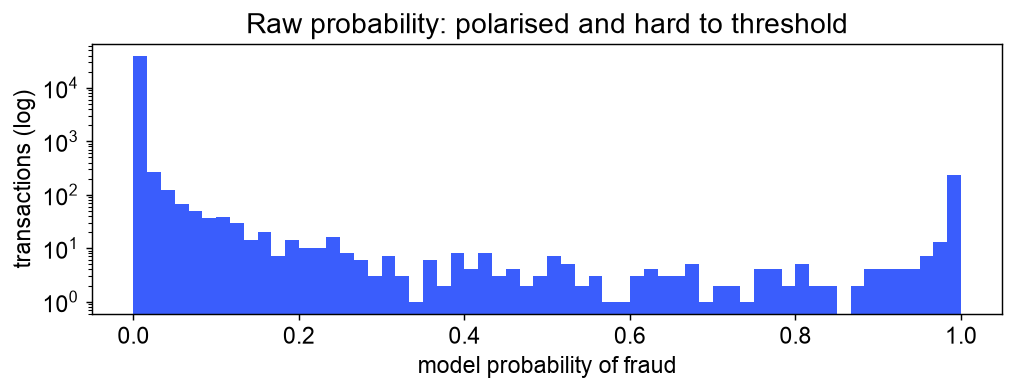

In [4]:
p_train = model.predict_proba(train[features])[:, 1]
p_test = model.predict_proba(test[features])[:, 1]

plt.figure(figsize=(8, 3.2), dpi=130)
plt.hist(p_train, bins=60, color="#3A5DFC")
plt.yscale("log")
plt.xlabel("model probability of fraud")
plt.ylabel("transactions (log)")
plt.title("Raw probability: polarised and hard to threshold")
plt.tight_layout()
plt.show()

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-brain" style="color:#18ab4b"></i>&nbsp; Deriving the score at training time (AFD's calibration)</h2>

The derivation happens once, on training data, and it reproduces Amazon Fraud Detector's calibration.

1. **Freeze a reference.** Take the probabilities the model assigns to the *legitimate* training transactions. `FPRCalibrator.fit` freezes this, and it ships with the model like the operating threshold.
2. **Read a probability as a false-positive rate.** A transaction's FPR is the share of legitimate transactions it outranks.
3. **Map the FPR through AFD's published anchors.** AFD's documentation pins the score to the FPR: 975 is a 0.5% rate, 900 is 2%, 700 is 7%, 600 is 10%. Interpolating through those points gives our score AFD's meaning.

In [5]:
calibrator = FPRCalibrator().fit(p_train, train["is_fraud"].values)
print(
    f"reference: {len(calibrator.legit_):,} legitimate training probabilities (frozen, ships with the model)"
)
list(zip(AFD_SCORE, AFD_FPR))  # AFD's published (score, FPR) anchor points

reference: 39,764 legitimate training probabilities (frozen, ships with the model)


[(np.int64(975), np.float64(0.005)),
 (np.int64(950), np.float64(0.01)),
 (np.int64(900), np.float64(0.02)),
 (np.int64(860), np.float64(0.03)),
 (np.int64(775), np.float64(0.05)),
 (np.int64(700), np.float64(0.07)),
 (np.int64(600), np.float64(0.1))]

The calibration curve is the score's definition: it passes through AFD's seven published points, and reading it the other way, a cut on the score is a false-alarm rate.

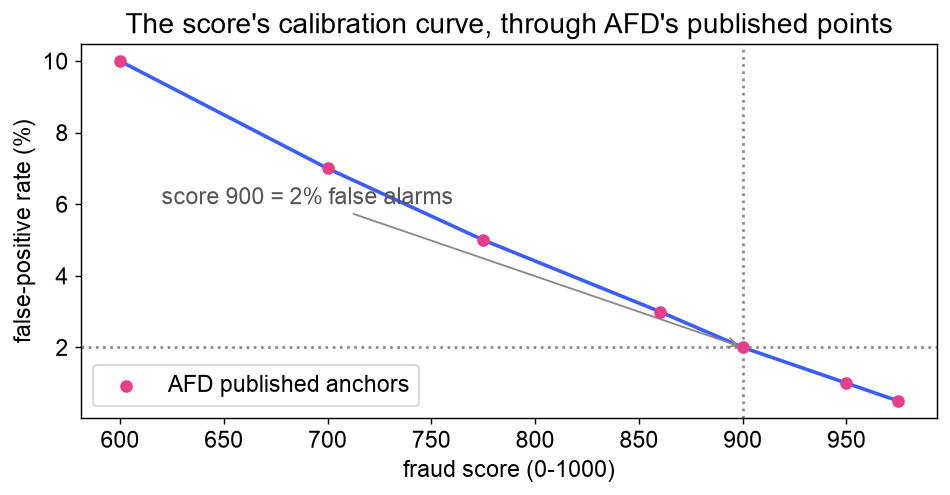

In [6]:
fpr_grid = np.linspace(0.005, 0.10, 200)
plt.figure(figsize=(7.5, 4), dpi=130)
plt.plot(np.interp(fpr_grid, AFD_FPR, AFD_SCORE), fpr_grid * 100, color="#3A5DFC", lw=2)
plt.scatter(
    AFD_SCORE, AFD_FPR * 100, color="#E4408A", zorder=5, label="AFD published anchors"
)
plt.axhline(2, color="#888", ls=":")
plt.axvline(900, color="#888", ls=":")
plt.annotate(
    "score 900 = 2% false alarms",
    (900, 2),
    (620, 6),
    color="#555",
    arrowprops=dict(arrowstyle="->", color="#888"),
)
plt.xlabel("fraud score (0-1000)")
plt.ylabel("false-positive rate (%)")
plt.title("The score's calibration curve, through AFD's published points")
plt.legend()
plt.tight_layout()
plt.show()

Sanity check: scoring the training rows and measuring the false-positive rate at each cut should reproduce AFD's table, a score of 900 really is a 2% rate, 775 a 5% rate, and so on.

In [7]:
s_train = calibrator.transform(p_train).ravel()
legit = np.sort(p_train[train["is_fraud"].values == 0])
rows = []
for cut, target in [(975, 0.5), (950, 1), (900, 2), (775, 5), (700, 7), (600, 10)]:
    mask = s_train >= cut
    fpr = (legit >= p_train[mask].min()).mean() if mask.any() else float("nan")
    rows.append((cut, round(100 * fpr, 2), target))
pd.DataFrame(rows, columns=["score cut", "measured FPR (%)", "AFD FPR (%)"])

,score cut,measured FPR (%),AFD FPR (%)
0,975,0.51,0.5
1,950,1.01,1.0
2,900,2.01,2.0
3,775,5.01,5.0
4,700,7.01,7.0
5,600,10.07,10.0


<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-bolt" style="color:#18ab4b"></i>&nbsp; Using the score at inference</h2>

Inference adds nothing to the derivation. A new transaction arrives, the model gives a probability, and the **same fitted calibrator** maps it to a 0 to 1000 score against the **frozen reference**. We score the held-out test set and split it into the three bands with `decide` (fraud >= 900, investigate >= 700, else approve).

In [8]:
s_test = calibrator.transform(p_test).ravel()
example = test[features].iloc[:5].copy()
example["probability"] = p_test[:5].round(4)
example["score"] = s_test[:5]
example["outcome"] = [decide(s) for s in s_test[:5]]
example[["amount_usd", "merchant_fraud_rate", "probability", "score", "outcome"]]

,amount_usd,merchant_fraud_rate,probability,score,outcome
0,7.21,0.0026,0.0,0,approve
1,61.76,0.0000,0.0,410,approve
2,21.00,0.0000,0.0,384,approve
3,17.14,0.0000,0.0,254,approve
4,36.83,0.0000,0.0,143,approve


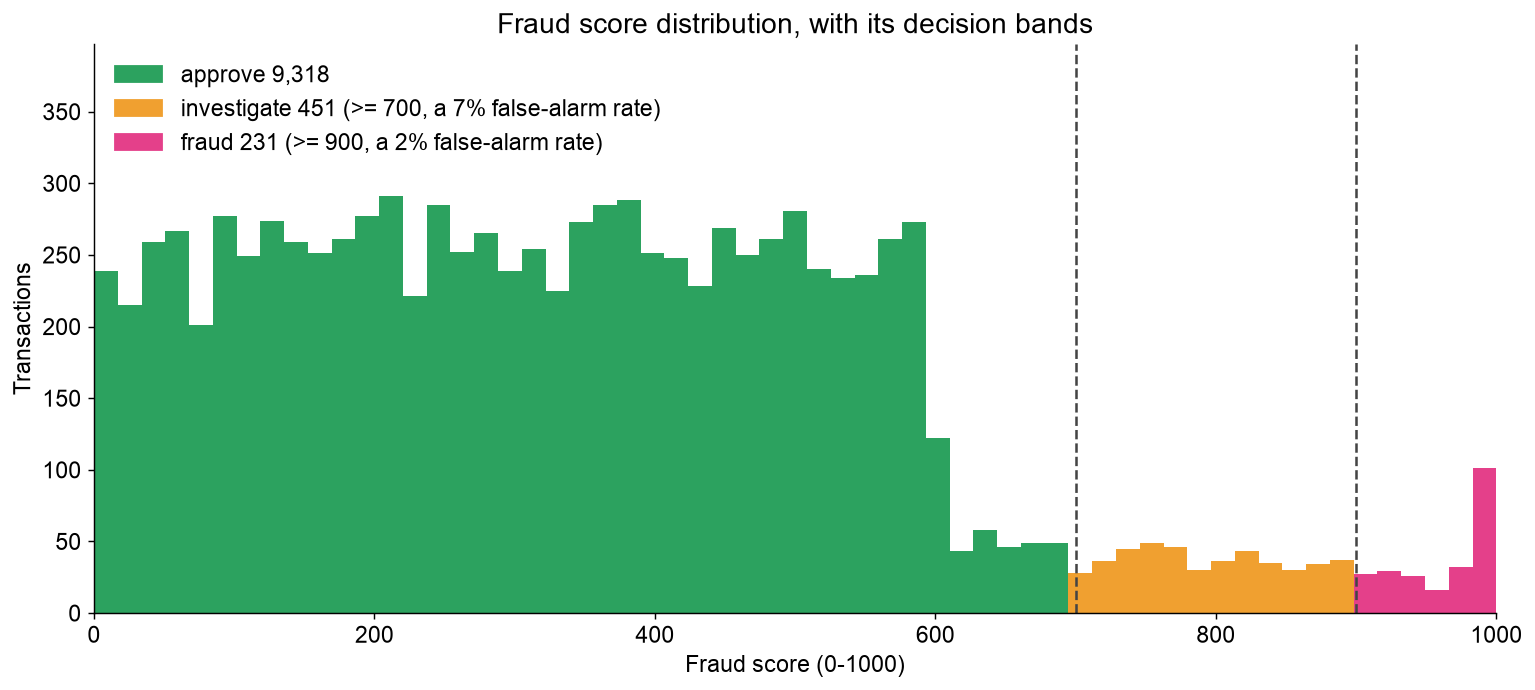

In [9]:
counts = {
    o: int(sum(decide(s) == o for s in s_test))
    for o in ("approve", "investigate", "fraud")
}
fig, ax = plt.subplots(figsize=(12, 5.5), dpi=130)
bins = np.linspace(0, 1000, 60)
for lo, hi, c in [
    (0, REVIEW_CUT, APPROVE),
    (REVIEW_CUT, FRAUD_CUT, INVESTIGATE),
    (FRAUD_CUT, 1001, FRAUD),
]:
    ax.hist(s_test[(s_test >= lo) & (s_test < hi)], bins=bins, color=c)
for x in (REVIEW_CUT, FRAUD_CUT):
    ax.axvline(x, color="#444", ls="--", lw=1.4)
ax.set_ylim(0, ax.get_ylim()[1] * 1.30)
ax.legend(
    handles=[
        mpatches.Patch(color=APPROVE, label=f"approve {counts['approve']:,}"),
        mpatches.Patch(
            color=INVESTIGATE,
            label=f"investigate {counts['investigate']:,} (>= {REVIEW_CUT}, a 7% false-alarm rate)",
        ),
        mpatches.Patch(
            color=FRAUD,
            label=f"fraud {counts['fraud']:,} (>= {FRAUD_CUT}, a 2% false-alarm rate)",
        ),
    ],
    loc="upper left",
    frameon=False,
    fontsize=13,
)
ax.set_xlim(0, 1000)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Fraud score (0-1000)")
ax.set_ylabel("Transactions")
ax.set_title("Fraud score distribution, with its decision bands")
plt.tight_layout()
plt.show()

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-users" style="color:#18ab4b"></i>&nbsp; Sizing the fraud desk: fraud arrives Poisson</h2>

The investigate band is a caseload, and a caseload needs people. How many analysts the desk needs follows from how fraud arrives. Count fraud in fine buckets, per minute, and the counts are Poisson: most minutes see none, a few see one. Fitting a Poisson to the chapter's own transactions confirms it, the curve sits on the observed bars (`src/scoring/incidence.py`).

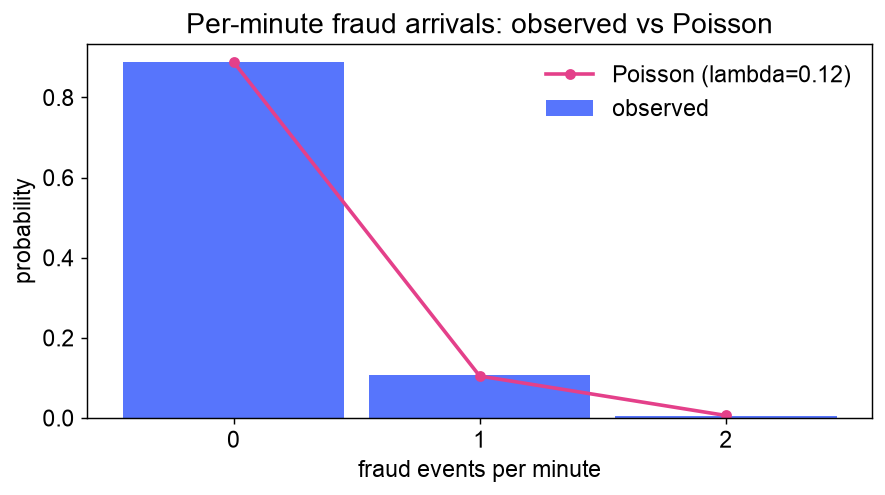

In [10]:
per_min = (
    train.assign(m=train["event_time"].dt.floor("min")).groupby("m")["is_fraud"].sum()
)
lam = per_min.mean()  # the fraud arrival rate
k = np.arange(0, int(per_min.max()) + 1)
observed = np.array([(per_min == i).mean() for i in k])
plt.figure(figsize=(7, 4), dpi=130)
plt.bar(k, observed, width=0.9, alpha=0.85, color="#3A5DFC", label="observed")
plt.plot(
    k,
    poisson.pmf(k, lam),
    color="#E4408A",
    lw=2,
    marker="o",
    ms=5,
    label=f"Poisson (lambda={lam:.2f})",
)
plt.xticks(k)
plt.xlabel("fraud events per minute")
plt.ylabel("probability")
plt.title("Per-minute fraud arrivals: observed vs Poisson")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-chart-line" style="color:#18ab4b"></i>&nbsp; Watching the score drift (DBShap)</h2>

Live traffic eventually stops looking like training. Compare the **live score distribution** to the frozen **training reference**, and when they diverge, attribute the gap to the input features that moved, a Shapley attribution in the spirit of DBShap (Edakunni et al.) that needs no labels because it works from the score alone. `ScoreDriftAttributor` holds the model and the calibrator, so it pickles and reruns batch to batch. A simulated merchant-targeted fraud campaign makes the drift visible.

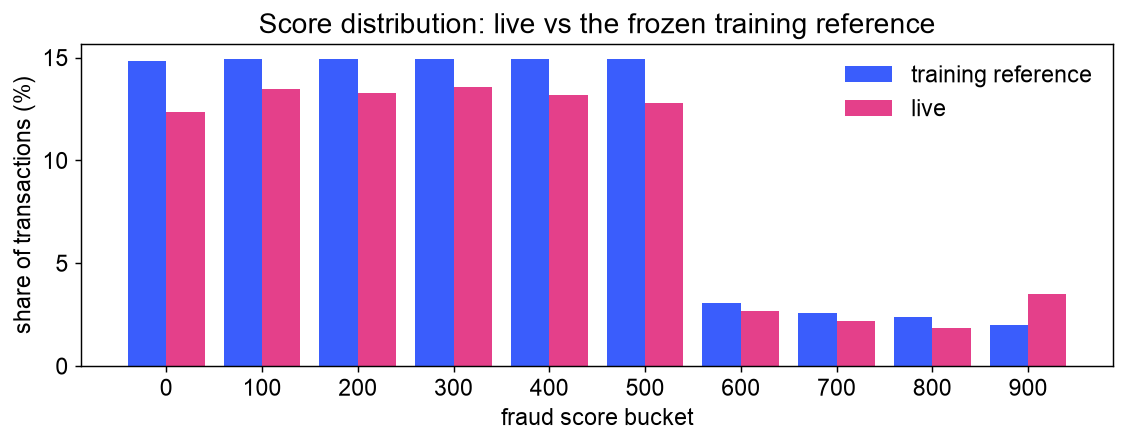

In [11]:
from drift import ScoreDriftAttributor

rng = np.random.default_rng(6)
burst = pd.concat([train, test])[lambda d: d["is_fraud"] == 1].sample(
    1500, replace=True, random_state=6
)
live = pd.concat([test, burst], ignore_index=True)
s_live = calibrator.transform(model.predict_proba(live[features])[:, 1]).ravel()

B = 100
ref = (
    pd.Series((s_train // B) * B)
    .value_counts(normalize=True)
    .reindex(range(0, 1000, B), fill_value=0)
)
liv = (
    pd.Series((s_live // B) * B)
    .value_counts(normalize=True)
    .reindex(range(0, 1000, B), fill_value=0)
)
x = np.arange(len(ref))
plt.figure(figsize=(9, 3.6), dpi=130)
plt.bar(x - 0.2, ref.values * 100, 0.4, label="training reference", color="#3A5DFC")
plt.bar(x + 0.2, liv.values * 100, 0.4, label="live", color="#E4408A")
plt.xticks(x, ref.index)
plt.xlabel("fraud score bucket")
plt.ylabel("share of transactions (%)")
plt.title("Score distribution: live vs the frozen training reference")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

total mean-score drift = 77.5  (= sum of contributions)


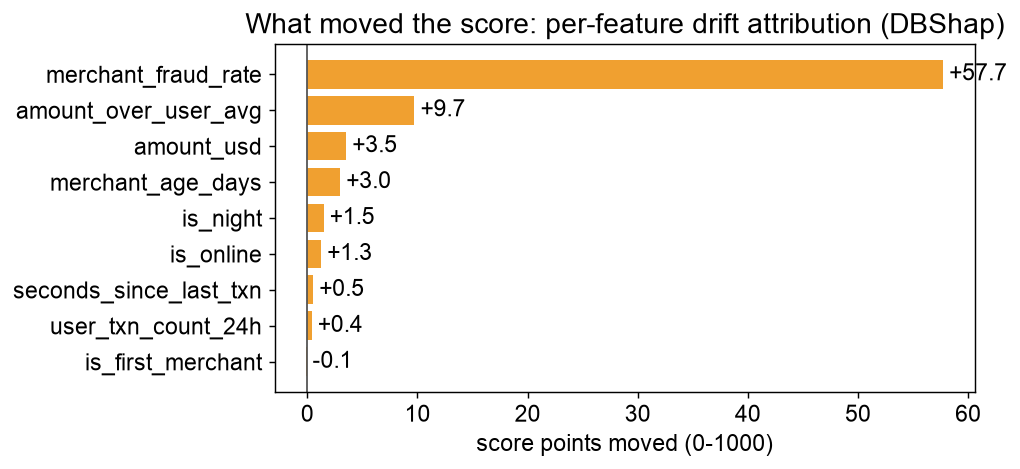

In [12]:
attrib = ScoreDriftAttributor(model, calibrator, features).fit(train).attribute(live)
print(f"total mean-score drift = {attrib.sum():.1f}  (= sum of contributions)")
ordered = attrib.sort_values()
plt.figure(figsize=(8, 3.8), dpi=130)
plt.barh(ordered.index, ordered.values, color="#F0A030")
for i, v in enumerate(ordered.values):
    plt.text(v, i, f" {v:+.1f}", va="center")
plt.axvline(0, color="#555", lw=1)
plt.xlabel("score points moved (0-1000)")
plt.title("What moved the score: per-feature drift attribution (DBShap)")
plt.tight_layout()
plt.show()

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-chart-bar" style="color:#18ab4b"></i>&nbsp; On the live board</h2>

`src/scoring/monitoring.py` fits the same `FPRCalibrator` and `ScoreDriftAttributor` and writes their results to the warehouse, which the Grafana board renders as the monitoring row: the daily live-score line, the live-versus-training distribution, and this attribution. Run it with `make monitor` while the local stack is up.